Notebook przedstawia zbudowanie sieci neuronowej typu CNN do rozpoznawania ręcznie pisanych cyfr ze zbioru MNIST. <br>
Program został napisany w języku programowania Python z wykorzystanie biblioteki programistycznej Tensorflow.

Kroki Instalacja potrzebnych bibliotek (modułów) języka Python.


In [18]:
!pip install -r https://raw.githubusercontent.com/datamllab/automl-in-action-notebooks/master/requirements.txt >/dev/null 2>&1



Ustawiamy początkowe ustawienie dla liczb losowych. Robimy to po to, żeby wyniki eksperymentu były powtarzalne.

In [19]:
import tensorflow as tf

tf.random.set_seed(42)


## Ładowanie danych cyfr ze zbioru danych MNIST


Oznaczenia:

train_images - to obrazy cyfr potrzebne do treningu <br>
train_labels - to etykiety tych cyfr (od 0 do 9) <br>
test_images  - to obrazy cyfr w testowym zbiorze danych <br>
test_labels  - to etykiety tych cyfr (od 0 do 9) <br>

In [20]:
from tensorflow.keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()


## Eskploracja/Przegląd Danych


In [21]:
train_images.shape, test_images.shape


((60000, 28, 28), (10000, 28, 28))

Obrazy to macierze złożony z liczb (pikseli) o wartościach od 0 do 255. Obrazy <br> są w odcieniach szartości, więc wystarczy jednak macierz do ich opisu. <br> W przypadku obrazów barwnych obrazy są kodowane za pomocą mechanismu RGB - obraz jest zapisywany w trzech macierzach, każdą odpowiadający za dany "kanał" obrazu. R - to kanał czerwony, G - to kanał zielonu, B - to kanał niebieski. <br> Zauważmy, że obrazów treningowych jest 60 tysięcy a testowych 10 tysięcy.
Trójwymiarowa macierz (wyobraźmy sobie prostopadłościan wypełniony liczbami) to tak zwany tensor. Stąd nazwa biblioteki programistycznej - tensorflow.

In [22]:
len(train_labels), len(test_labels)


(60000, 10000)

In [23]:
train_labels, test_labels


(array([5, 0, 4, ..., 5, 6, 8], dtype=uint8),
 array([7, 2, 1, ..., 4, 5, 6], dtype=uint8))

In [24]:
min(train_labels), max(train_labels), min(test_labels), max(test_labels)

(np.uint8(0), np.uint8(9), np.uint8(0), np.uint8(9))

Tutaj wyświetlamy podgląd zbiorów z etykietami. Są to mecierze jednowymiarowe, które zawierają liczby od 0 do 9.

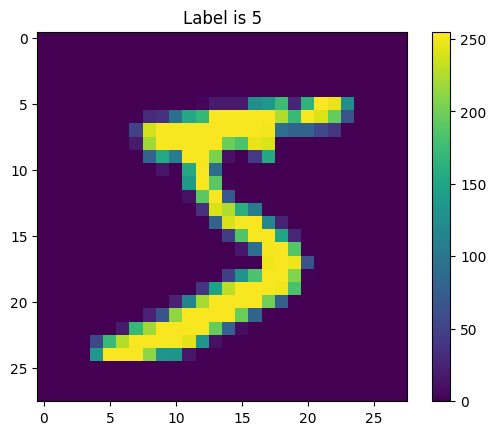

In [25]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(train_images[0])  # , cmap='gray'
plt.colorbar()
plt.title("Label is {label}".format(label=train_labels[0]))
plt.show()


## Przygotowanie danych: skalowanie


Część algorytmów uczenia maszynowego wymaga, aby dane zostały przeskalowane. <br> Zachowujemy "odległości" między danymi, ale ścieśniamy je do mniejszego zakresu. <br> Tutaj przykładowo z zakresu (0 - 255) do zakresu (0-1). <br>
Gdy jest bardzo duża rozpiętość danych algorytmu uczą się dłużej i ich nauka jest mniej stabilna - raz uczą w dobrą stronę raz nie.

In [26]:
train_images = train_images / 255.0
test_images = test_images / 255.0


In [27]:
%matplotlib inline


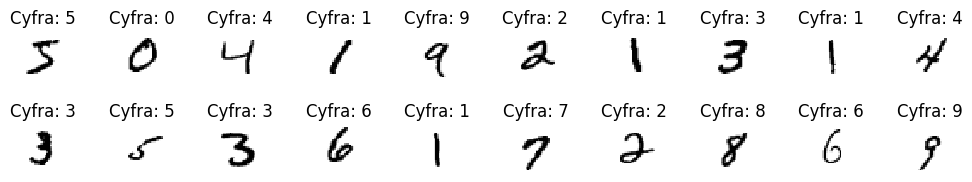

In [28]:
import matplotlib
import matplotlib.pyplot as plt

# plot first 20 images
n = 20
_, axes = plt.subplots(2, 10, figsize=(10, 2))
plt.tight_layout()
for i in range(n):
    row, col = i // 10, i % 10
    axes[row, col].set_axis_off()
    axes[row, col].imshow(
        train_images[
            i,
        ],
        cmap=plt.cm.binary,
        interpolation="nearest",
    )  # plt.cm.gray_r
    axes[row, col].set_title("Cyfra: %i" % train_labels[i])


Wyświetlamy 20 pierwszych cyfr ze zbioru treningowego oraz ich etykiety.

## Budowanie sieci neuronowej (wielowarstwowoej - MLP)


In [29]:

def build_cnn():
    model = keras.Sequential(
        [
            keras.layers.Conv2D(
                32, (3, 3), activation="relu", input_shape=train_images.shape[1:] + (1,)
            ),
            keras.layers.MaxPooling2D((2, 2)),
            keras.layers.Conv2D(64, (3, 3), activation="relu"),
            keras.layers.MaxPooling2D((2, 2)),
            keras.layers.Conv2D(64, (3, 3), activation="relu"),
            keras.layers.Flatten(),
            keras.layers.Dense(64, activation="relu"),
            keras.layers.Dense(10, activation="softmax"),
        ]
    )

    model.compile(
        optimizer="adam",
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )
    return model



Tutaj budujemy sieć neuronową do rozpoznania obrazów cyfr. <br>
Sieć zawiera kilka warstw operacji konwolucji oraz próbkowania (pooling). <br>
Ostatnimi warstwami jest spłaszczanie oraz aktywacja sieci. <br>
Optimilizatorem (algorytmem), który będzie odopwiedzialny za uczenie się w sieci (minimalizacja funkcji błędu) będzie algorytm ADAM (właściwa nazwa to Adaptive Moment Estimation)

In [30]:
from tensorflow import keras
from tensorflow.keras import layers
cnn_model = build_cnn()


In [31]:
cnn_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

Podsumowanie naszej sieci. Widzimy, że sieć zawiera 93322 parametry <br>, których finalne wartości będą ustalone w procesie uczenia się sieci. <br>
Opisana jest także każda warstwa - z wymariowością macierzy po przeprocesowaniu <br> przez tą wartwę.

In [32]:
train_images_4d = train_images[..., tf.newaxis]
test_images_4d = test_images[..., tf.newaxis]
train_images_4d.shape, test_images_4d.shape


((60000, 28, 28, 1), (10000, 28, 28, 1))

In [33]:
cnn_model.fit(train_images_4d, train_labels, epochs=5, batch_size=64, verbose=1)


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 53s 55ms/step - accuracy: 0.9445 - loss: 0.1829
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 50s 53ms/step - accuracy: 0.9829 - loss: 0.0527
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 50s 54ms/step - accuracy: 0.9888 - loss: 0.0369
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 54ms/step - accuracy: 0.9915 - loss: 0.0280
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 51s 55ms/step - accuracy: 0.9931 - loss: 0.0220


Tutaj możemy zaobserwować proces uczenia się sieci neuronowej. <br>
Proces składa się z 5 epoch. Każdy epoch to pełne przejście przez dane treningowe. <br>
Przyjrzymy się dokładnie wartościam w każdej epoce. Weźmy przykładowo pierwszą z nich.  <br>
Epoch 1/5 <br>
938/938 ━━━━━━━━━━━━━━━━━━━━ 58s 58ms/step - accuracy: 0.9413 - loss: 0.1898 <br>
Podczas tej epoki wykonany 938 kroków (batchy). <br>
Wartości wag są aktualizowane po każdym kroku <br>
58s - cała epoka trwała 58 sekund. <br>
Jeden krok zajął średnio 58 milisekund <br>
accuracy: 0.9413. Dokładność sieci po tej opcje wyniosła 94.13 % <br>
loss: 0.1898. Wartość funkcji błędu na koniec epoki. <br>
Podczas kolejnych epok zwykle oczekujemy, że loss będzie malał, a accuracy rosło.



In [34]:
test_loss, test_acc = cnn_model.evaluate(test_images_4d, test_labels, verbose=0)
test_acc


0.9817000031471252

Uruchamiamy nasz model na danych testowych. <br>
Dokładność wyniosła 98.91%

## Użycie sieci neurnowej


Poniżej sprawdzimy jak sieć działa. Najpierw wykonamy rozpoznanie 3 cyfr wybranych z testowego zbioru danych. <br>
Będą to cyfry o numerach 0, 3, 1023.
Dodatkowo mamy też możliwość narysowania własnej cyfry i sprawdzić jak sieć <br>sobie z tym radzi. Ja przykładowo narysowałem cyfrę 8 i nie dopełniłem do <br>końca "brzuszków". Sieć przewidziała że jest to cyfra 8 na 94%, cyfra 2 na 5% <br>

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


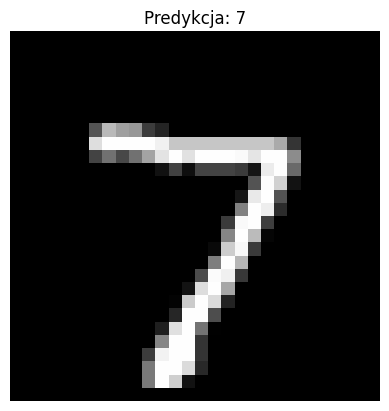

In [35]:
import matplotlib.pyplot as plt
import numpy as np


test_predictions = cnn_model.predict(test_images_4d)

i = 0  # numer przykładu

plt.imshow(test_images_4d[i].squeeze(), cmap='gray')
plt.title(f"Predykcja: {np.argmax(test_predictions[i])}")
plt.axis('off')
plt.show()

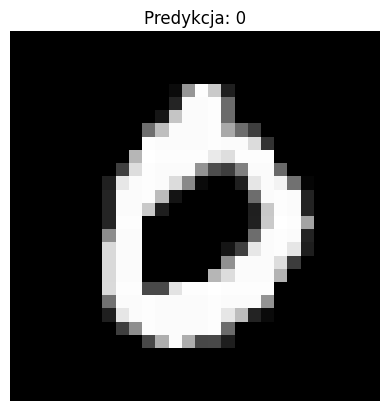

In [36]:
import matplotlib.pyplot as plt
import numpy as np

i = 3  # numer przykładu

plt.imshow(test_images_4d[i].squeeze(), cmap='gray')
plt.title(f"Predykcja: {np.argmax(test_predictions[i])}")
plt.axis('off')
plt.show()


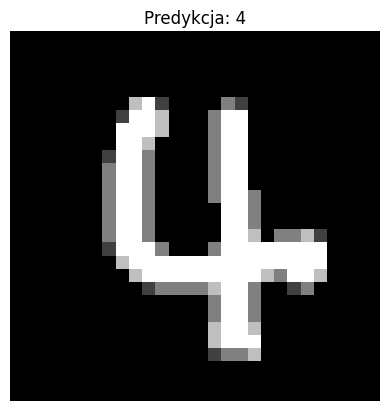

In [37]:
import matplotlib.pyplot as plt
import numpy as np

i = 1023  # numer przykładu

plt.imshow(test_images_4d[i].squeeze(), cmap='gray')
plt.title(f"Predykcja: {np.argmax(test_predictions[i])}")
plt.axis('off')
plt.show()


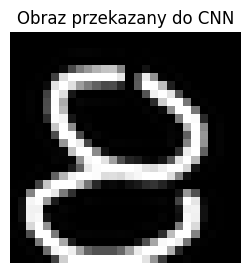

Shape: (1, 28, 28, 1)
Min: 0.0
Max: 1.0


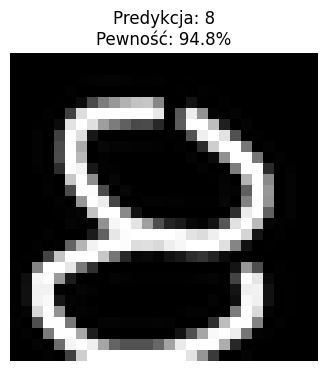

Sieć rozpoznała cyfrę: 8
Pewność: 94.8%


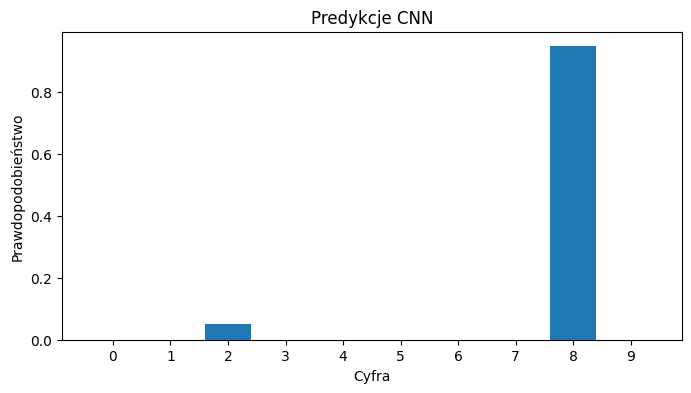

In [45]:
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display, HTML
from google.colab.output import eval_js

from PIL import Image
from io import BytesIO
import base64


# ============================================================
# 1. Funkcja pozwalająca narysować cyfrę myszką
# ============================================================

def draw_digit():

    canvas_html = """
    <div style="text-align:center;">

        <h3>Narysuj cyfrę</h3>

        <canvas id="canvas"
                width="280"
                height="280"
                style="
                    border:3px solid #555;
                    background:black;
                    cursor:crosshair;
                    touch-action:none;
                ">
        </canvas>

        <br><br>

        <button id="recognize"
                style="
                    font-size:18px;
                    padding:10px 20px;
                    margin-right:10px;
                ">
            Rozpoznaj cyfrę
        </button>

        <button id="clear"
                style="
                    font-size:18px;
                    padding:10px 20px;
                ">
            Wyczyść
        </button>

    </div>

    <script>

    const canvas = document.getElementById("canvas");
    const ctx = canvas.getContext("2d");

    // czarne tło
    ctx.fillStyle = "black";
    ctx.fillRect(0, 0, canvas.width, canvas.height);

    // ustawienia pisaka
    ctx.strokeStyle = "white";
    ctx.lineWidth = 20;
    ctx.lineCap = "round";
    ctx.lineJoin = "round";

    let drawing = false;


    function getPosition(event) {

        const rect = canvas.getBoundingClientRect();

        const x = event.clientX - rect.left;
        const y = event.clientY - rect.top;

        return {x, y};
    }


    // rozpoczęcie rysowania

    canvas.addEventListener("pointerdown", function(event) {

        drawing = true;

        const pos = getPosition(event);

        ctx.beginPath();
        ctx.moveTo(pos.x, pos.y);

        canvas.setPointerCapture(event.pointerId);
    });


    // rysowanie

    canvas.addEventListener("pointermove", function(event) {

        if (!drawing)
            return;

        const pos = getPosition(event);

        ctx.lineTo(pos.x, pos.y);
        ctx.stroke();
    });


    // zakończenie rysowania

    canvas.addEventListener("pointerup", function(event) {

        drawing = false;
        ctx.closePath();

    });


    canvas.addEventListener("pointercancel", function(event) {

        drawing = false;

    });


    // wyczyszczenie obrazu

    document.getElementById("clear").onclick = function() {

        ctx.fillStyle = "black";
        ctx.fillRect(0, 0, canvas.width, canvas.height);

    };


    // zwracamy obraz po kliknięciu Rozpoznaj

    window.digitData = new Promise(resolve => {

        document.getElementById("recognize").onclick = function() {

            resolve(canvas.toDataURL("image/png"));

        };

    });

    </script>
    """

    display(HTML(canvas_html))

    # Python czeka na kliknięcie "Rozpoznaj cyfrę"
    data = eval_js("digitData")

    return data


# ============================================================
# 2. RYSOWANIE
# ============================================================

data = draw_digit()


# ============================================================
# 3. Konwersja obrazu z Canvas -> PIL
# ============================================================

image_data = data.split(",")[1]

image_bytes = base64.b64decode(image_data)

img = Image.open(BytesIO(image_bytes)).convert("L")


# ============================================================
# 4. Skalowanie 280x280 -> 28x28
# ============================================================

img = img.resize((28, 28), Image.Resampling.LANCZOS)


# ============================================================
# 5. Konwersja do numpy
# ============================================================

digit = np.array(img).astype("float32")


# ============================================================
# 6. Normalizacja 0-255 -> 0-1
# ============================================================

digit = digit / 255.0


# ============================================================
# 7. Wyświetlenie tego, co zobaczy sieć
# ============================================================

plt.figure(figsize=(3,3))

plt.imshow(
    digit,
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title("Obraz przekazany do CNN")
plt.axis("off")
plt.show()


# ============================================================
# 8. Format wymagany przez CNN
#
# (28,28)
#       ↓
# (1,28,28,1)
# ============================================================

digit_4d = digit.reshape(1, 28, 28, 1)


print("Shape:", digit_4d.shape)
print("Min:", digit_4d.min())
print("Max:", digit_4d.max())


# ============================================================
# 9. Predykcja
# ============================================================

prediction = cnn_model.predict(digit_4d, verbose=0)

predicted_digit = np.argmax(prediction[0])

confidence = prediction[0][predicted_digit]


# ============================================================
# 10. Wynik
# ============================================================

plt.figure(figsize=(4,4))

plt.imshow(
    digit,
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title(
    f"Predykcja: {predicted_digit}\n"
    f"Pewność: {confidence:.1%}"
)

plt.axis("off")
plt.show()


print("Sieć rozpoznała cyfrę:", predicted_digit)
print(f"Pewność: {confidence:.1%}")


# ============================================================
# 11. Prawdopodobieństwa wszystkich cyfr
# ============================================================

plt.figure(figsize=(8,4))

plt.bar(
    range(10),
    prediction[0]
)

plt.xticks(range(10))

plt.xlabel("Cyfra")
plt.ylabel("Prawdopodobieństwo")
plt.title("Predykcje CNN")

plt.show()

Zachęcam Państwa do samodzielnych eksperymentów.